In [2]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import kagglehub

# Download the dataset
dataset_path = kagglehub.dataset_download("afridirahman/brain-stroke-ct-image-dataset")

# Construct correct paths
normal_path = os.path.join(dataset_path, "Brain_Data_Organised", "Normal")
stroke_path = os.path.join(dataset_path, "Brain_Data_Organised", "Stroke")

# List files
normal_folder = os.listdir(normal_path)
stroke_folder = os.listdir(stroke_path)

# Read and preprocess images
data = []
labels = []

def load_images(folder_path, label):
    images = []
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        try:
            image = Image.open(img_path).resize((224, 224)).convert('RGB')
            images.append(np.array(image, dtype=np.float32))  # Convert to float
            labels.append(label)
        except Exception as e:
            print(f"Error loading {img_file}: {e}")
    return images

data.extend(load_images(normal_path, 0))  # Normal class (label = 0)
data.extend(load_images(stroke_path, 1))  # Stroke class (label = 1)

# Convert lists to NumPy arrays
x = np.array(data) / 255.0  # Normalize
y = np.array(labels)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, shuffle=True, random_state=42)
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)




Train shape: (2000, 224, 224, 3) Test shape: (501, 224, 224, 3)


In [3]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU

cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), strides=1, padding="valid", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=2),
    Conv2D(64, kernel_size=(3,3), strides=1, padding="valid", activation="relu"),
    MaxPooling2D(pool_size=2),
    Conv2D(128, kernel_size=(3,3), strides=1, padding="valid", activation="relu"),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])
cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
print("CNN Model Summary:")
cnn_model.summary()
cnn_history = cnn_model.fit(x_train, y_train, batch_size=32, epochs=15)

CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,277,697 (84.98 MB)

 Trainable params: 22,277,697 (84.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.6060 - loss: 0.7737
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8002 - loss: 0.4062
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9248 - loss: 0.1816
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9735 - loss: 0.0752
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9900 - loss: 0.0354
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9925 - loss: 0.0195
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9974 - loss: 0.0105
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9952 - loss: 0.0173
Epoch 9/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9994 - loss: 0.0045
Epoch 10/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9940 - loss: 0.0151
Epoch 11/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9942 - loss: 0.0123
Epoch 12/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accurac

In [5]:
# Evaluate CNN model
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test, verbose=1)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9765 - loss: 0.0803
CNN Test Accuracy: 0.9760


In [6]:
from sklearn.metrics import classification_report, accuracy_score
cnn_preds = cnn_model.predict(x_test)
cnn_preds_binary = (cnn_preds > 0.5).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [7]:
print("CNN Model Performance:")
print(classification_report(y_test, cnn_preds_binary))

CNN Model Performance:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       305
           1       0.97      0.96      0.97       196

    accuracy                           0.98       501
   macro avg       0.98      0.97      0.97       501
weighted avg       0.98      0.98      0.98       501



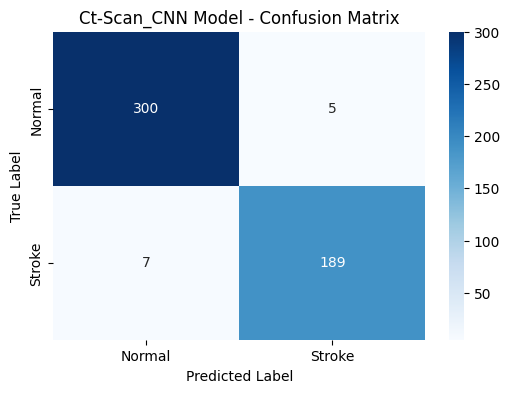

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cnn_cm = confusion_matrix(y_test, cnn_preds_binary)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Normal', 'Stroke'], yticklabels=['Normal', 'Stroke'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ct-Scan_CNN Model - Confusion Matrix")
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


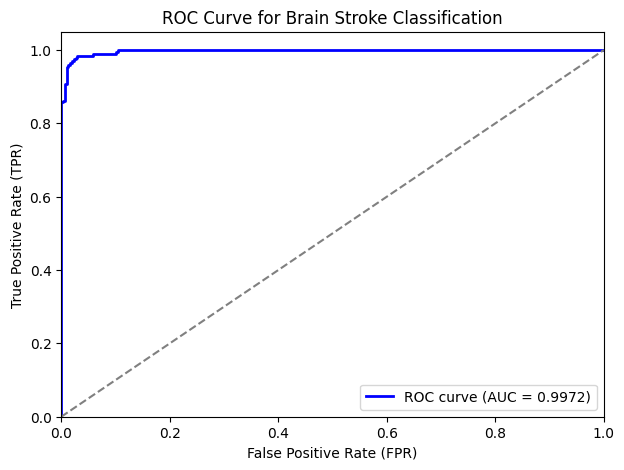

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Get prediction probabilities for the stroke class (NOT binary labels)
y_pred_probs = cnn_model.predict(x_test)  # Probabilities for class 1 (Stroke)

# Step 2: Compute the ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)  # FPR, TPR
roc_auc = auc(fpr, tpr)  # Compute AUC score

# Step 3: Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Brain Stroke Classification")
plt.legend(loc="lower right")
plt.show()



In [14]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define dataset paths in Google Drive
dataset_path = "/content/drive/MyDrive/DS"  # Change to your actual path
normal_path = os.path.join(dataset_path, "normal")
stroke_path = os.path.join(dataset_path, "stroke")

# Read and preprocess images
data = []
labels = []

def load_images(folder_path, label):
    images = []
    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        try:
            image = Image.open(img_path).resize((224, 224)).convert('RGB')
            data.append(np.array(image, dtype=np.float32) / 255.0)  # Normalize and append
            labels.append(label)
        except Exception as e:
            print(f"Error loading {img_file}: {e}")

# Load images from both classes
load_images(normal_path, 0)  # Normal class (label = 0)
load_images(stroke_path, 1)  # Stroke class (label = 1)

# Convert lists to NumPy arrays
x = np.array(data)
y = np.array(labels)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Evaluate CNN model
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x, y, verbose=1)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5318 - loss: 2.2076
CNN Test Accuracy: 0.5813


In [17]:
from sklearn.metrics import classification_report

# Predict the classes for the test set
cnn_preds = cnn_model.predict(x)

# Convert probabilities to binary values (0 or 1)
cnn_preds_binary = (cnn_preds > 0.5).astype(int)

# Generate the classification report
print("CNN Model Performance:")
print(classification_report(y, cnn_preds_binary))

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
CNN Model Performance:
              precision    recall  f1-score   support

           0       0.63      0.58      0.60       896
           1       0.53      0.59      0.56       728

    accuracy                           0.58      1624
   macro avg       0.58      0.58      0.58      1624
weighted avg       0.59      0.58      0.58      1624



In [18]:
import pickle

# Save model architecture and weights separately
model_json = cnn_model.to_json()  # Convert model architecture to JSON
model_weights = cnn_model.get_weights()  # Extract weights

# Save architecture and weights in a pickle file
with open("cnn_brain_stroke_model.pkl", "wb") as f:
    pickle.dump({"architecture": model_json, "weights": model_weights}, f)

print("Model saved successfully in .pkl format!")


Model saved successfully in .pkl format!


In [19]:
from google.colab import files
files.download("cnn_brain_stroke_model.pkl")  # This will download the file to your local system


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pickle
from tensorflow.keras.models import model_from_json

# Path to the saved model in Google Drive (update with your actual path)
pkl_model_path = "/content/drive/MyDrive/cnn_brain_stroke_model.pkl"

# Load the pickle file
with open(pkl_model_path, "rb") as f:
    model_data = pickle.load(f)

# Recreate the model from architecture
loaded_model = model_from_json(model_data["architecture"])

# Load the weights into the model
loaded_model.set_weights(model_data["weights"])

print("Model loaded successfully from Google Drive!")


Model loaded successfully from Google Drive!


In [25]:
from google.colab import files
from PIL import Image
import numpy as np

# Upload an image
uploaded = files.upload()

# Get the filename of the uploaded image
image_path = list(uploaded.keys())[0]

# Load and preprocess the image
image = Image.open(image_path).resize((224, 224)).convert('RGB')  # Resize & convert to RGB
image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension

# Predict using the loaded model
prediction = loaded_model.predict(image_array)
predicted_class = "Stroke" if prediction[0][0] > 0.5 else "Normal"

print(f"Prediction: {predicted_class} (Confidence: {prediction[0][0]:.4f})")


Saving download.jpg to download.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction: Stroke (Confidence: 1.0000)
